In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [3]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=28, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [4]:
class ContrastiveDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        img, target = self.base_dataset[idx]

        view1 = self.transform(img)
        view2 = self.transform(img)

        return view1, view2, target

In [5]:
mnist_train_base = datasets.MNIST(root='./data', train=True, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=basic_transform)

In [6]:
contrastive_train_dataset = ContrastiveDataset(mnist_train_base, contrastive_transform)

batch_size = 256

contrastive_loader = DataLoader(contrastive_train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

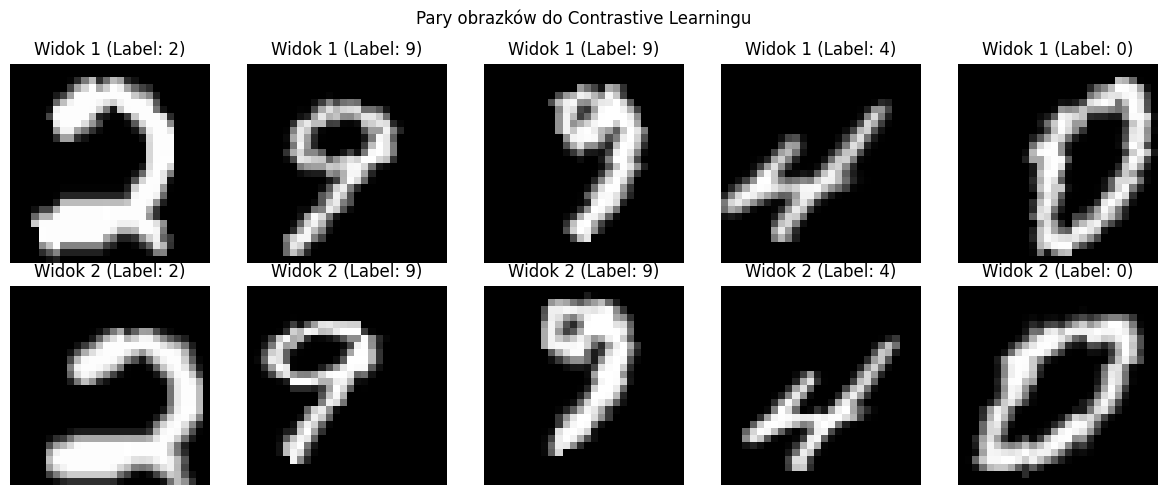

In [7]:
views1, views2, labels = next(iter(contrastive_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(views1[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"Widok 1 (Label: {labels[i]})")
    axes[0, i].axis('off')

    axes[1, i].imshow(views2[i].squeeze(), cmap='gray')
    axes[1, i].set_title(f"Widok 2 (Label: {labels[i]})")
    axes[1, i].axis('off')
plt.suptitle("Pary obrazków do Contrastive Learningu")
plt.tight_layout()
plt.show()

In [8]:
class SimCLRNet(nn.Module):
    def __init__(self, rep_dim=128, proj_dim=64):
        super(SimCLRNet, self).__init__()

        self.encoder = nn.Sequential(
            # wejście 1x28x28
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # wyjście 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # wyjście 32x7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, rep_dim)
        )

        self.projector = nn.Sequential(
            nn.Linear(rep_dim, rep_dim),
            nn.ReLU(),
            nn.Linear(rep_dim, proj_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        # intuicja jest taka, że 'z' jest dobre dla contrastive loss, ale wynik encodera 'h' lepiej bedzie sluzyl do samej klasyfikacji
        return h, z

simclr_model = SimCLRNet().to(device)
print(simclr_model)

SimCLRNet(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=1568, out_features=128, bias=True)
  )
  (projector): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
)


In [9]:
def contrastive_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    z = torch.cat([z1, z2], dim=0)

    sim_matrix = torch.matmul(z, z.T) / temperature

    labels = torch.cat([torch.arange(batch_size, 2 * batch_size), 
                        torch.arange(batch_size)], dim=0).to(device)

    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(device)
    sim_matrix.masked_fill_(mask, -1e15)

    loss = F.cross_entropy(sim_matrix, labels)
    return loss

In [10]:
optimizer_simclr = optim.Adam(simclr_model.parameters(), lr=0.001)
epochs_simclr = 10 
model_path = "simclr_mnist_wieghts.pth"

In [11]:
if os.path.exists(model_path):
    print(f"Wczytujmey zapisane wagi modeu '{model_path}'")
    simclr_model.load_state_dict(torch.load(model_path, map_location=device))
else:
    for epoch in range(epochs_simclr):
        simclr_model.train()
        running_loss = 0.0
        
        for view1, view2, _ in tqdm(contrastive_loader, desc="Training"):
            view1, view2 = view1.to(device), view2.to(device)
            
            optimizer_simclr.zero_grad()
            
            _, z1 = simclr_model(view1)
            _, z2 = simclr_model(view2)
            
            loss = contrastive_loss(z1, z2)
            
            loss.backward()
            optimizer_simclr.step()
            
            running_loss += loss.item()
            
        avg_loss = running_loss / len(contrastive_loader)
        print(f"Epoka [{epoch+1}/{epochs_simclr}], Loss: {avg_loss:.4f}")

    torch.save(simclr_model.state_dict(), model_path)
    print(f"Model zapisany jako '{model_path}'.")

Training: 100%|██████████| 234/234 [00:17<00:00, 13.16it/s]


Epoka [1/10], Loss: 4.8463


Training: 100%|██████████| 234/234 [00:17<00:00, 13.20it/s]


Epoka [2/10], Loss: 4.5997


Training: 100%|██████████| 234/234 [00:18<00:00, 12.89it/s]


...

Epoka [8/10], Loss: 4.4947


Training: 100%|██████████| 234/234 [00:18<00:00, 12.71it/s]


Epoka [9/10], Loss: 4.4863


Training: 100%|██████████| 234/234 [00:18<00:00, 12.59it/s]

Epoka [10/10], Loss: 4.4832
Model zapisany jako 'simclr_mnist_wieghts.pth'.


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [13]:
print("Ekstrakcja cech dla 10 000 zdjęć testowych...")
simclr_model.eval()
test_reps = []
test_labels_list = []

Ekstrakcja cech dla 10 000 zdjęć testowych...


In [14]:
with torch.no_grad(): # przechodzimy na cpu, bo sklearn nie radzi sobie z gpu, mps
    for imgs, lbls in tqdm(test_loader, desc="Test set"):
        imgs = imgs.to(device)
        h, _ = simclr_model(imgs)
        test_reps.append(h.cpu().numpy())
        test_labels_list.append(lbls.numpy())

X_test = np.concatenate(test_reps)
y_test = np.concatenate(test_labels_list)

Test set: 100%|██████████| 40/40 [00:00<00:00, 90.13it/s]


In [18]:
sample_sizes = [5, 10, 20, 50, 100]

log_accs = []
knn_accs = []

for n_samples in sample_sizes:
    class_counts = {i: 0 for i in range(10)}
    few_shot_images = []
    few_shot_labels = []

    # szukamy N przykładów z każdej klasy
    for img, label in mnist_train_base:
        if class_counts[label] < n_samples:
            few_shot_images.append(basic_transform(img))
            few_shot_labels.append(label)
            class_counts[label] += 1
        if sum(class_counts.values()) == 10 * n_samples:
            break

    few_shot_images = torch.stack(few_shot_images).to(device)
    y_train = np.array(few_shot_labels)

    # Ekstrakcja cech dla tych N przykładów
    with torch.no_grad():
        X_train = simclr_model(few_shot_images)[0].cpu().numpy()

    # Trening LogReg
    log_clf = LogisticRegression(max_iter=1000)
    log_clf.fit(X_train, y_train)
    log_acc = accuracy_score(y_test, log_clf.predict(X_test)) * 100
    
    # Trening kNN
    knn_clf = KNeighborsClassifier(n_neighbors=3)
    knn_clf.fit(X_train, y_train)
    knn_acc = accuracy_score(y_test, knn_clf.predict(X_test)) * 100

    print(f"Próbki na klasę: {n_samples:<2} (Łącznie etykiet: {n_samples*10:<3}) | LogReg ACC: {log_acc:.2f}% | kNN ACC: {knn_acc:.2f}%")

    log_accs.append(log_acc)
    knn_accs.append(knn_acc)

Próbki na klasę: 5  (Łącznie etykiet: 50 ) | LogReg ACC: 78.37% | kNN ACC: 59.63%
Próbki na klasę: 10 (Łącznie etykiet: 100) | LogReg ACC: 85.45% | kNN ACC: 69.84%
Próbki na klasę: 20 (Łącznie etykiet: 200) | LogReg ACC: 91.71% | kNN ACC: 77.74%
Próbki na klasę: 50 (Łącznie etykiet: 500) | LogReg ACC: 94.48% | kNN ACC: 84.28%
Próbki na klasę: 100 (Łącznie etykiet: 1000) | LogReg ACC: 95.44% | kNN ACC: 88.41%


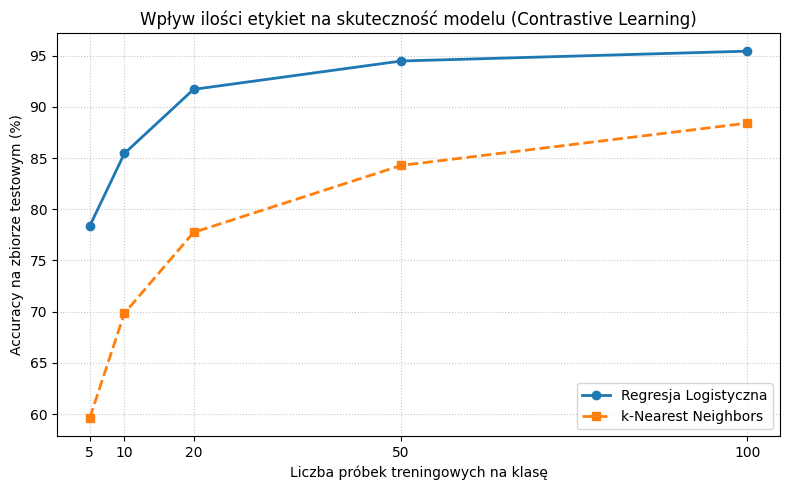

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, log_accs, marker='o', linestyle='-', color='tab:blue', label='Regresja Logistyczna', linewidth=2)
plt.plot(sample_sizes, knn_accs, marker='s', linestyle='--', color='tab:orange', label='k-Nearest Neighbors', linewidth=2)

plt.title('Wpływ ilości etykiet na skuteczność modelu (Contrastive Learning)', fontsize=12)
plt.xlabel('Liczba próbek treningowych na klasę', fontsize=10)
plt.ylabel('Accuracy na zbiorze testowym (%)', fontsize=10)
plt.xticks(sample_sizes) 
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Bardzo dobre wyniki. Ciekawy ten trening.  

Najpier ternujemy model self-supervised tak że obchodzi nas tylko contrastive_loss, tak jakby etykiet nie było.

Featury, których model uczy się po drodze okazują się już byc wystarczające dla porstego modelu jak LogReg czy kNN i to jeszcze trening może być na małym ułamku danych olabelowanych. 

Bardzo fajne.